In [1]:
# predict the price of the car using the variables or features

In [2]:
import piplite
await piplite.install('seaborn')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<ipython-input-3-b478a6fd18e5>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [4]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

In [5]:
file_path= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"

await download(file_path, "usedcars.csv")
file_name="usedcars.csv"

In [6]:
df = pd.read_csv(file_name)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [7]:
# x: the predictor/independent variable
# y: the response/dependent variable (that we want to predict)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lm = LinearRegression()
lm

LinearRegression()

In [10]:
X = df[['highway-mpg']]
Y = df['price']

In [11]:
lm.fit(X,Y)

LinearRegression()

In [12]:
Yhat=lm.predict(X)
Yhat[0:5]

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

In [13]:
lm.intercept_

38423.30585815743

In [14]:
lm.coef_

array([-821.73337832])

In [15]:
# Price = 38423.31 - 821.73 x highway-mpg

In [16]:
lm1 = LinearRegression()

In [17]:
lm1.fit(df[['engine-size']], df[['price']])
lm1

LinearRegression()

In [18]:
lm1.coef_

array([[166.86001569]])

In [19]:
lm1.intercept_

array([-7963.33890628])

In [20]:
# Multiple Linear Regression

In [21]:
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

In [22]:
lm.fit(Z, df['price'])

LinearRegression()

In [23]:
lm.intercept_

-15806.62462632922

In [24]:
lm.coef_

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

In [26]:
lm2 = LinearRegression()
X2 = df[['normalized-losses','highway-mpg']]
lm2.fit(X2, df['price'])

LinearRegression()

In [27]:
# coefficient
lm2.coef_

array([   1.49789586, -820.45434016])

In [28]:
# intercept_
lm2.intercept_

38201.313272457344

In [29]:
import seaborn as sns
%matplotlib inline

(0.0, 48170.388737179455)

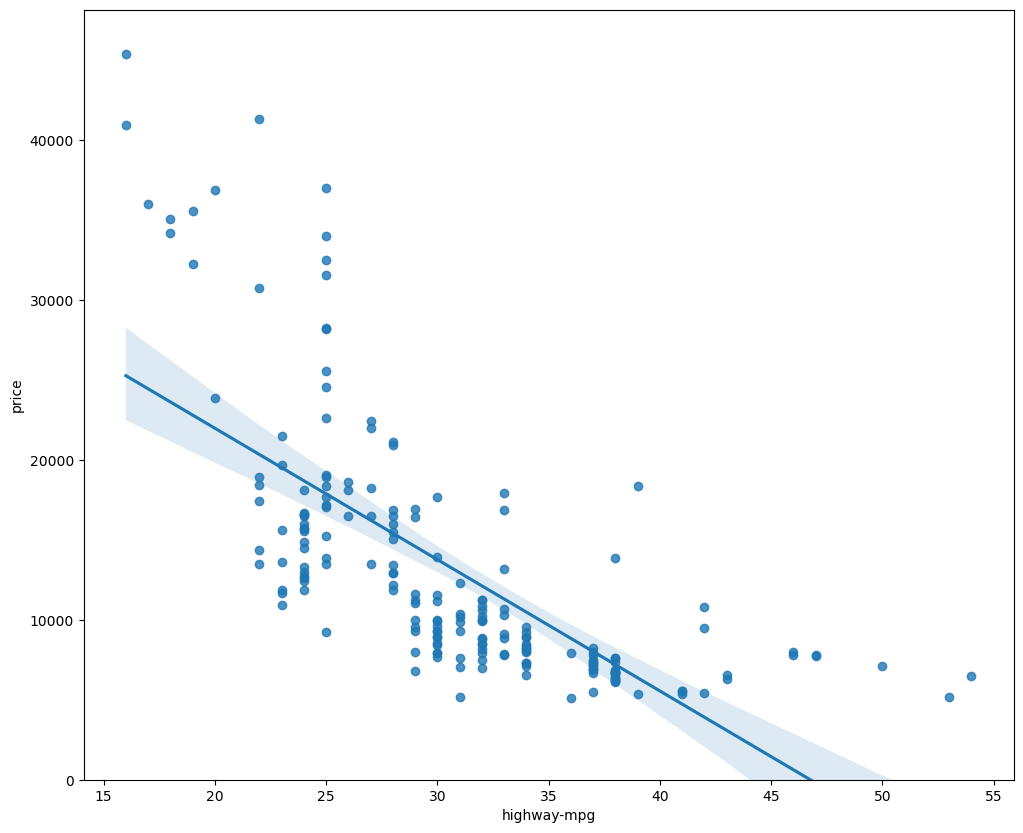

In [34]:
# linear regression - use regression plots
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x='highway-mpg', y='price', data=df)
plt.ylim(0,)

(0.0, 47414.1)

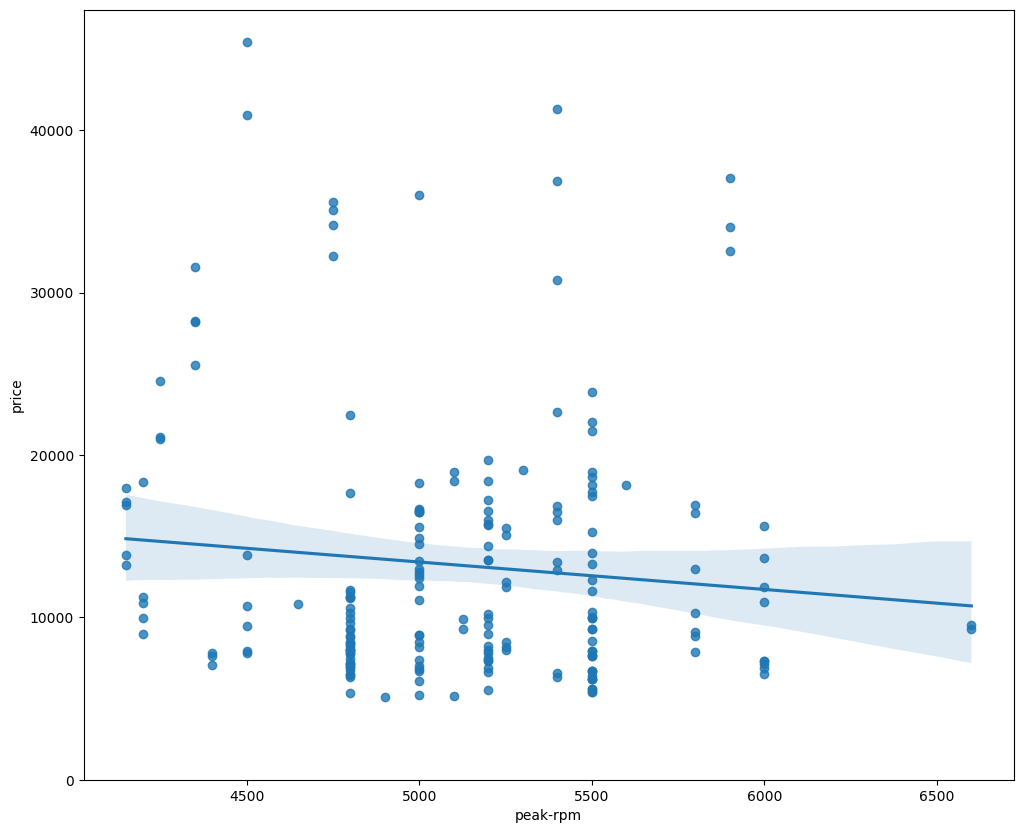

In [35]:
plt.figure(figsize=(width, height))
sns.regplot(x='peak-rpm', y='price', data=df)
plt.ylim(0,)

In [36]:
df[['peak-rpm', 'highway-mpg','price']].corr()

,peak-rpm,highway-mpg,price
peak-rpm,1.000000,-0.058598,-0.101616
highway-mpg,-0.058598,1.000000,-0.704692
price,-0.101616,-0.704692,1.000000


In [37]:
# Residual Plot to visualize the variance of the data

In [38]:
# Yhat : predicted value
# y: observed value
# e(residual) = Yhat - y

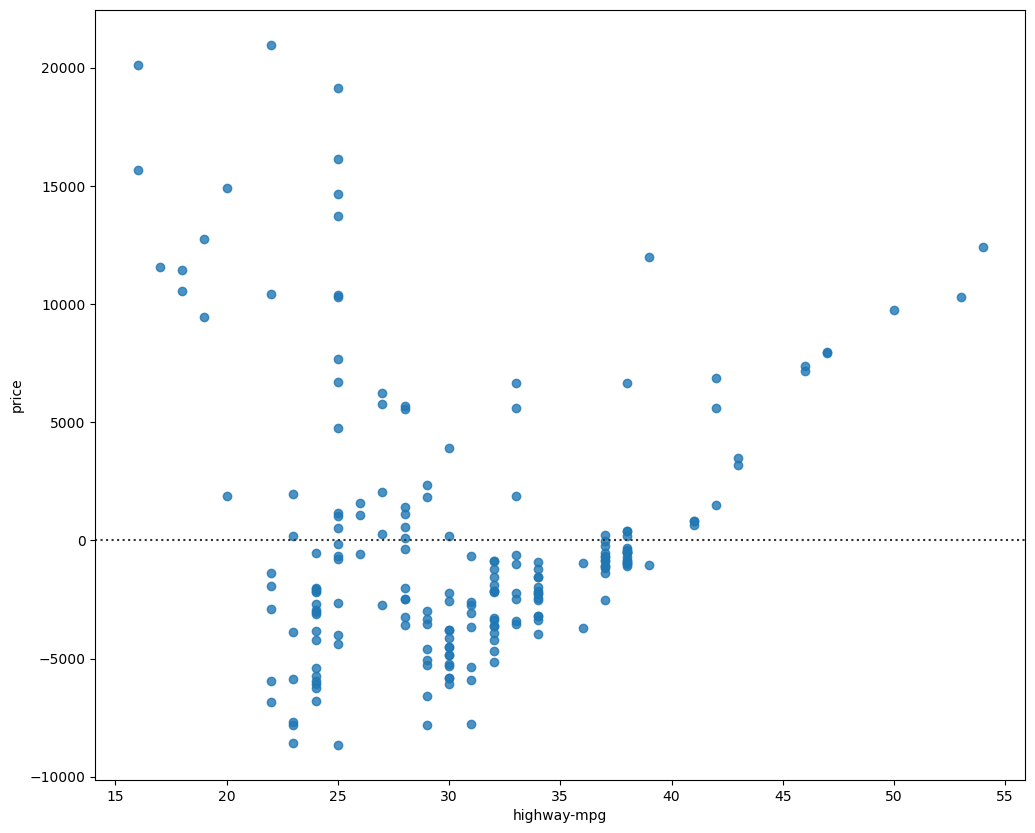

In [39]:
width = 12
height = 10
plt.figure(figsize=(width, height))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

In [40]:
Y_hat = lm.predict(Z)

<ipython-input-41-31600473fbe3>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color='r', label='Actual Value')
<ipython-input-41-31600473fbe3>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_hat, hist=False, color='b', label='Fitted Values',

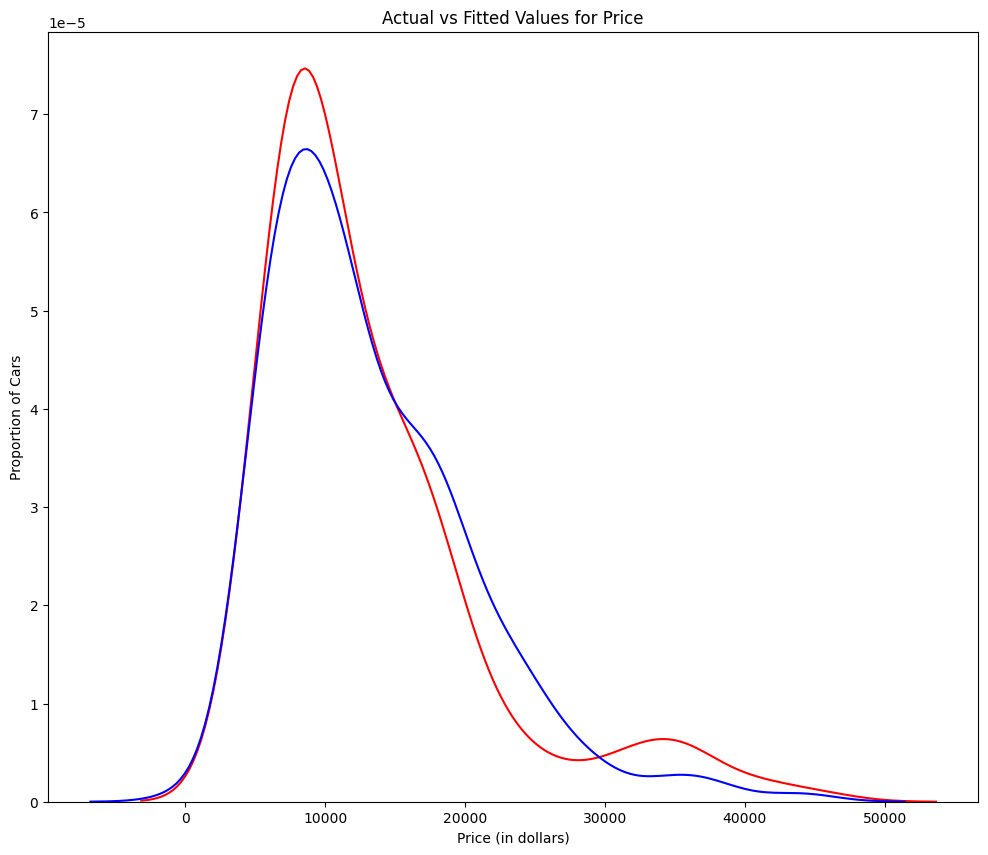

In [41]:
plt.figure(figsize=(width, height))

ax1 = sns.distplot(df['price'], hist=False, color='r', label='Actual Value')
sns.distplot(Y_hat, hist=False, color='b', label='Fitted Values', ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

In [42]:
# Polynomial Regression and Pipelines

In [43]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

In [44]:
x = df['highway-mpg']
y = df['price']

In [46]:
# Here we use a polynomial of the 3rd order (cubic) 
f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


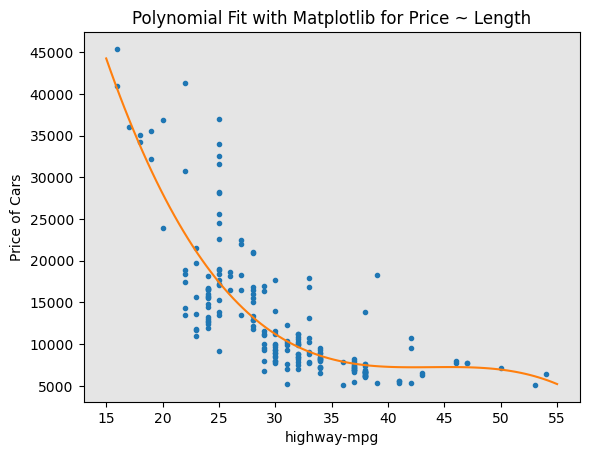

In [47]:
PlotPolly(p, x, y, 'highway-mpg')

In [48]:
np.polyfit(x,y,3)

array([-1.55663829e+00,  2.04754306e+02, -8.96543312e+03,  1.37923594e+05])

            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08


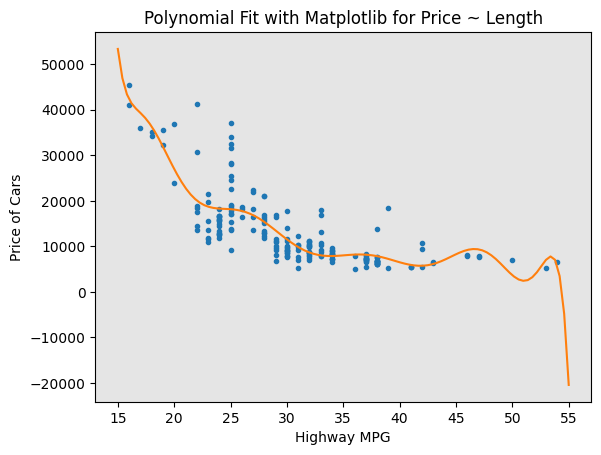

In [49]:
f1 = np.polyfit(x,y,11)
p1 = np.poly1d(f1)
print(p1)
PlotPolly(p1,x,y,'Highway MPG')

In [50]:
from sklearn.preprocessing import PolynomialFeatures

In [51]:
pr=PolynomialFeatures(degree=2)
pr

PolynomialFeatures()

In [53]:
Z_pr=pr.fit_transform(Z)

In [54]:
Z.shape

(201, 4)

In [55]:
Z_pr.shape

(201, 15)

In [56]:
#Pipeline

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [58]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

In [59]:
pipe=Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [60]:
Z = Z.astype(float)
pipe.fit(Z,y)

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [61]:
ypipe=pipe.predict(Z)
ypipe[0:4]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555])

In [62]:
Input=[('scale',StandardScaler()),
      ('model',LinearRegression())]

pipe=Pipeline(Input)
# produce a prediction using a linear regression model using the features Z and target y
pipe.fit(Z,y) 

ypipe=pipe.predict(Z)
ypipe[0:10]

array([13699.11161184, 13699.11161184, 19051.65470233, 10620.36193015,
       15521.31420211, 13869.66673213, 15456.16196732, 15974.00907672,
       17612.35917161, 10722.32509097])

In [63]:
# MEasures for In-Sample Evaluation

In [64]:
lm.fit(X,Y)
print('The R-square is: ', lm.score(X,Y))

The R-square is:  0.4965911884339176


In [65]:
Yhat=lm.predict(X)
print('The output of the first four predicted value is: ', Yhat[0:4])

The output of the first four predicted value is:  [16236.50464347 16236.50464347 17058.23802179 13771.3045085 ]


In [66]:
from sklearn.metrics import mean_squared_error

In [67]:
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The mean square error of price and predicted value is:  31635042.944639888


In [68]:
# Multiple Linear Regression

In [69]:
# fit the model 
lm.fit(Z, df['price'])
# Find the R^2
print('The R-square is: ', lm.score(Z, df['price']))

The R-square is:  0.8093562806577457


In [70]:
Y_predict_multifit = lm.predict(Z)

In [71]:
print('The mean square error of price and predicted value using multifit is: ', \
      mean_squared_error(df['price'], Y_predict_multifit))

The mean square error of price and predicted value using multifit is:  11980366.87072649


In [72]:
#Polynomial Fit

In [73]:
from sklearn.metrics import r2_score

In [74]:
r_squared = r2_score(y, p(x))
print('The R-square value is: ', r_squared)

The R-square value is:  0.674194666390652


In [75]:
# MSE

In [76]:
mean_squared_error(df['price'], p(x))

20474146.426361218

In [77]:
# Prediction and Decision Making

In [78]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline 

In [79]:
new_input=np.arange(1, 100, 1).reshape(-1, 1)

In [80]:
lm.fit(X, Y)
lm

LinearRegression()

In [81]:
yhat=lm.predict(new_input)
yhat[0:5]

/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([37601.57247984, 36779.83910151, 35958.10572319, 35136.37234487,
       34314.63896655])

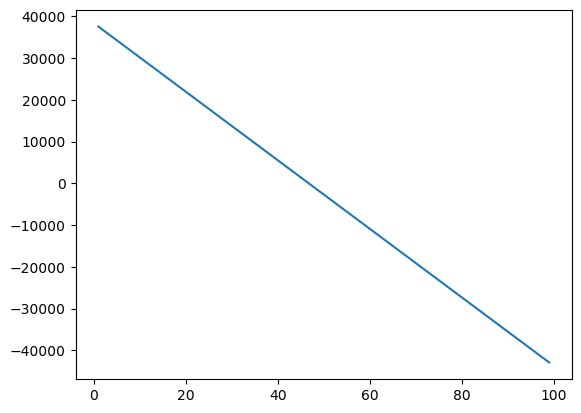

In [82]:
plt.plot(new_input, yhat)
plt.show()